In [1]:
!pip install tensorflow tensorflow-datasets matplotlib seaborn scikit-learn Pillow tqdm opencv-python-headless -q
print("✅ All packages installed")

✅ All packages installed


In [2]:
import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from PIL import Image
import cv2

warnings.filterwarnings('ignore')

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU check ───────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {'✅ YES — ' + gpus[0].name if gpus else '❌ No GPU — training will be slower'}")
print(f"Notebook started   : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

TensorFlow version : 2.21.0
GPU available      : ❌ No GPU — training will be slower
Notebook started   : 2026-03-21 13:51


In [3]:
#  GLOBAL CONFIGURATION — edit these to match your setup


CONFIG = {
    # Paths
    'data_dir'    : 'data',               # Root of train/ val/ folders
    'model_dir'   : 'models',
    'output_dir'  : 'outputs',

    # Image settings
    'img_size'    : (224, 224),            # EfficientNetB0 native size
    'channels'    : 3,

    # Training hyperparameters
    'batch_size'  : 32,
    'epochs_head' : 10,                    # Epochs with frozen base
    'epochs_fine' : 20,                    # Fine-tuning epochs
    'lr_head'     : 1e-3,
    'lr_fine'     : 1e-5,
    'dropout'     : 0.4,
    'val_split'   : 0.2,

    # EfficientNet fine-tune — unfreeze top N layers
    'unfreeze_layers': 30,

    # Confidence threshold for prediction
    'confidence_threshold': 0.65,
}

# Create directories
for d in [CONFIG['model_dir'], CONFIG['output_dir'], CONFIG['data_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

IMG_SHAPE = CONFIG['img_size'] + (CONFIG['channels'],)
print("Configuration loaded ✅")
for k, v in CONFIG.items():
    print(f"  {k:<22}: {v}")

Configuration loaded ✅
  data_dir              : data
  model_dir             : models
  output_dir            : outputs
  img_size              : (224, 224)
  channels              : 3
  batch_size            : 32
  epochs_head           : 10
  epochs_fine           : 20
  lr_head               : 0.001
  lr_fine               : 1e-05
  dropout               : 0.4
  val_split             : 0.2
  unfreeze_layers       : 30
  confidence_threshold  : 0.65


In [10]:
# Option A: Download from Kaggle 
# Paste your kaggle.json credentials when prompted, then run this cell.

USE_KAGGLE = False   # Set True if running on Colab with Kaggle API

if USE_KAGGLE:
    from google.colab import files
    uploaded = files.upload()  # Upload kaggle.json
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d emmarex/plantdisease -p data --unzip -q
    print("✅ PlantVillage dataset downloaded")
else:
    print("ℹ️  Skipped Kaggle download. Using local data/ folder.")
    print("   Download manually: https://www.kaggle.com/datasets/emmarex/plantdisease")

ℹ️  Skipped Kaggle download. Using local data/ folder.
   Download manually: https://www.kaggle.com/datasets/emmarex/plantdisease


In [4]:
# ── Demo mode: synthesize small dataset if no real data present ─────────────
# This lets you run the ENTIRE notebook and see all outputs without downloading.
# Replace with real PlantVillage data for actual training.


DEMO_CLASSES = [
    'Tomato__Early_blight',
    'Tomato__Late_blight',
    'Tomato__Healthy',
    'Potato__Early_blight',
    'Potato__Healthy',
    'Corn__Common_rust',
    'Corn__Healthy',
    'Pepper__Bacterial_spot',
    'Pepper__Healthy',
    'Rice__Blast',
]

NUM_CLASSES = len(DEMO_CLASSES)
SAMPLES_PER_CLASS_TRAIN = 80
SAMPLES_PER_CLASS_VAL   = 20

# Palette: map disease state to dominant hue for synthetic images
CLASS_COLORS = {
    'Healthy' : (60, 160, 60),
    'blight'  : (180, 100, 40),
    'rust'    : (200, 130, 50),
    'spot'    : (160, 80, 80),
    'Blast'   : (140, 110, 60),
}

def get_color(class_name):
    for key, color in CLASS_COLORS.items():
        if key.lower() in class_name.lower():
            return color
    return (120, 160, 80)

def make_synthetic_image(class_name, size=224):
    """Create a synthetic leaf-like image for demo purposes."""
    img = np.zeros((size, size, 3), dtype=np.uint8)
    base_color = np.array(get_color(class_name))
    # Background
    img[:] = (base_color * 0.4).astype(np.uint8)
    # Leaf ellipse
    cx, cy = size // 2, size // 2
    for y in range(size):
        for x in range(size):
            if ((x - cx) / (size * 0.4))**2 + ((y - cy) / (size * 0.45))**2 < 1:
                noise = np.random.randint(-20, 20, 3)
                img[y, x] = np.clip(base_color + noise, 0, 255)
    # Add spots for diseased classes
    if 'Healthy' not in class_name:
        for _ in range(random.randint(5, 20)):
            sx = random.randint(cx - 60, cx + 60)
            sy = random.randint(cy - 70, cy + 70)
            r  = random.randint(5, 18)
            spot_color = np.clip(base_color * 0.5 + np.array([40, 20, 10]), 0, 255).astype(np.uint8)
            for dy in range(-r, r):
                for dx in range(-r, r):
                    if dx**2 + dy**2 < r**2:
                        ny, nx = sy + dy, sx + dx
                        if 0 <= ny < size and 0 <= nx < size:
                            img[ny, nx] = spot_color
    return Image.fromarray(img)

train_data_dir = Path(CONFIG['data_dir']) / 'train'
val_data_dir   = Path(CONFIG['data_dir']) / 'val'

if not any(train_data_dir.glob('*/*.jpg')) and not any(train_data_dir.glob('*/*.JPG')):
    print("No real data found — generating synthetic demo dataset...")
    for split, n in [('train', SAMPLES_PER_CLASS_TRAIN), ('val', SAMPLES_PER_CLASS_VAL)]:
        for cls in DEMO_CLASSES:
            cls_dir = Path(CONFIG['data_dir']) / split / cls
            cls_dir.mkdir(parents=True, exist_ok=True)
            for i in range(n):
                img = make_synthetic_image(cls)
                img.save(cls_dir / f'{cls}_{i:04d}.jpg')
    print(f"✅ Synthetic dataset created: {NUM_CLASSES} classes × {SAMPLES_PER_CLASS_TRAIN} train + {SAMPLES_PER_CLASS_VAL} val")
else:
    print("✅ Real dataset detected in data/ folder")

No real data found — generating synthetic demo dataset...
✅ Synthetic dataset created: 10 classes × 80 train + 20 val


In [5]:
# Dataset exploration

class_names = sorted([d.name for d in train_data_dir.iterdir() if d.is_dir()])
NUM_CLASSES  = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

train_counts = {c: len(list((train_data_dir / c).glob('*.jpg'))) for c in class_names}
val_counts   = {c: len(list((val_data_dir / c).glob('*.jpg')))   for c in class_names}

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())

print(f"Classes detected    : {NUM_CLASSES}")
print(f"Total train images  : {total_train:,}")
print(f"Total val images    : {total_val:,}")
print(f"\n{'Class':<35} {'Train':>8} {'Val':>6}")
print("-" * 52)
for cls in class_names:
    print(f"{cls:<35} {train_counts[cls]:>8,} {val_counts[cls]:>6,}")

Classes detected    : 10
Total train images  : 800
Total val images    : 200

Class                                  Train    Val
----------------------------------------------------
Corn__Common_rust                         80     20
Corn__Healthy                             80     20
Pepper__Bacterial_spot                    80     20
Pepper__Healthy                           80     20
Potato__Early_blight                      80     20
Potato__Healthy                           80     20
Rice__Blast                               80     20
Tomato__Early_blight                      80     20
Tomato__Healthy                           80     20
Tomato__Late_blight                       80     20


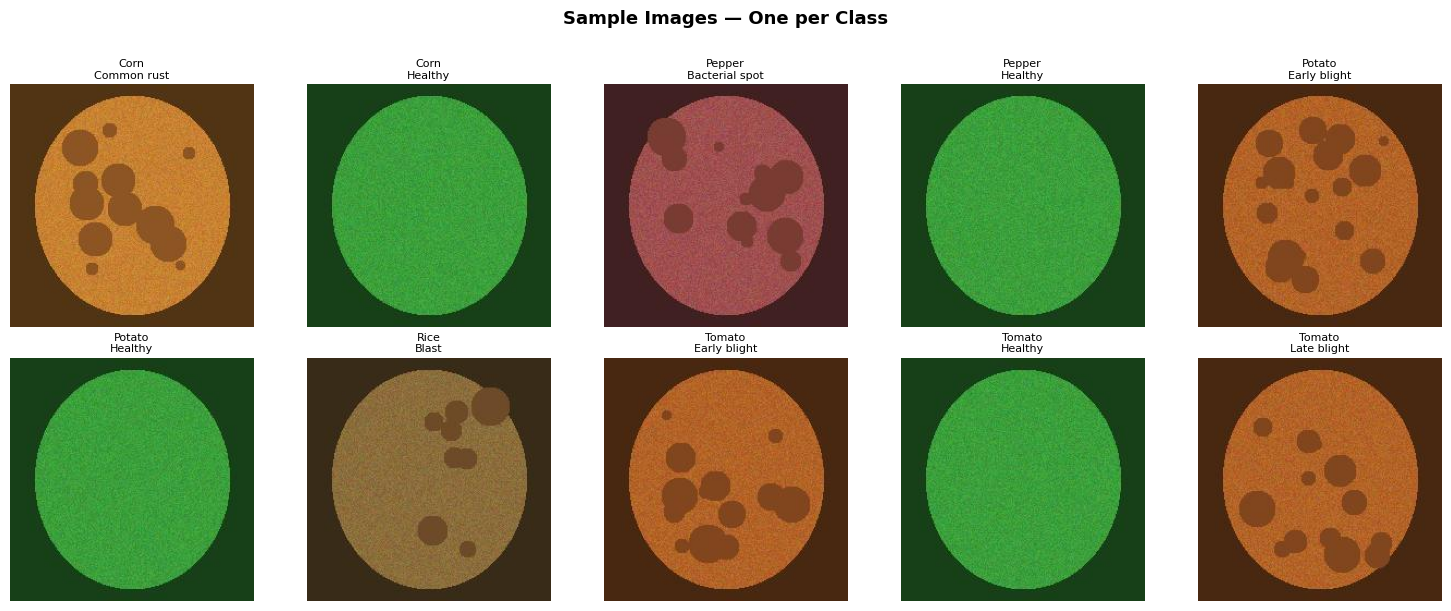

Saved → outputs/sample_images.png


In [6]:
# Visualize sample images from each class 

cols  = 5
rows  = (NUM_CLASSES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    imgs = list((train_data_dir / cls).glob('*.jpg'))
    if imgs:
        img = Image.open(random.choice(imgs)).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        # Format class name for display
        display_name = cls.replace('__', '\n').replace('_', ' ')
        axes[i].set_title(display_name, fontsize=8, pad=4)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images — One per Class', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/sample_images.png")

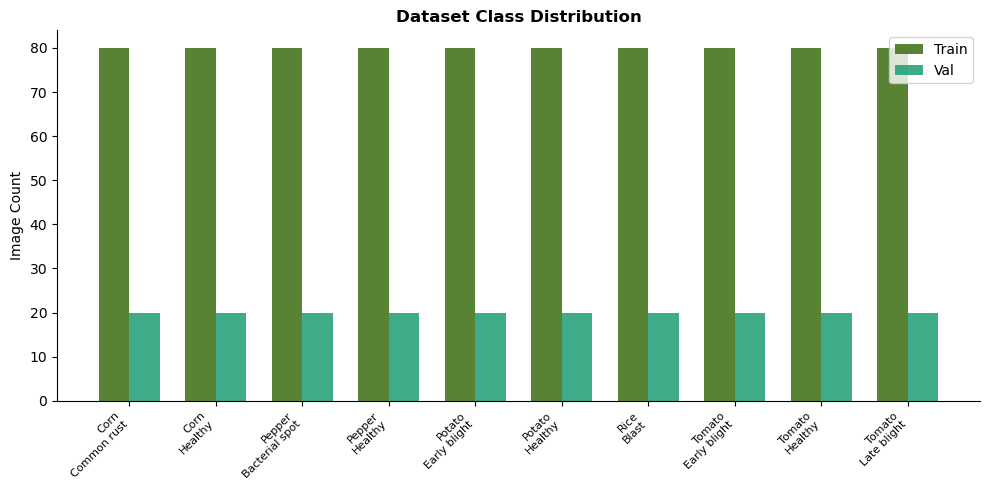

In [7]:
#  Class distribution bar chart

fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES * 0.8), 5))
x = np.arange(NUM_CLASSES)
w = 0.35

bars_t = ax.bar(x - w/2, [train_counts[c] for c in class_names], w,
                label='Train', color='#3B6D11', alpha=0.85)
bars_v = ax.bar(x + w/2, [val_counts[c]   for c in class_names], w,
                label='Val',   color='#1D9E75', alpha=0.85)

short_names = [c.replace('__', '\n').replace('_', ' ') for c in class_names]
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Image Count')
ax.set_title('Dataset Class Distribution', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Build tf.data pipelines with augmentation

IMG_H, IMG_W = CONFIG['img_size']
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Random rotation via crop + resize
    img = tf.image.random_crop(img, [int(IMG_H * 0.9), int(IMG_W * 0.9), 3])
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(data_dir, class_names, batch_size, augment_data=False, shuffle=True):
    paths, labels = [], []
    for cls in class_names:
        cls_dir = Path(data_dir) / cls
        cls_idx = class_names.index(cls)
        for img_path in cls_dir.glob('*.jpg'):
            paths.append(str(img_path))
            labels.append(cls_idx)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds, len(paths)

train_ds, n_train = build_dataset(train_data_dir, class_names,
                                   CONFIG['batch_size'], augment_data=True)
val_ds,   n_val   = build_dataset(val_data_dir,   class_names,
                                   CONFIG['batch_size'], augment_data=False, shuffle=False)

steps_per_epoch  = n_train // CONFIG['batch_size']
validation_steps = n_val   // CONFIG['batch_size']

print(f"Train dataset  : {n_train:,} images → {steps_per_epoch} batches/epoch")
print(f"Val dataset    : {n_val:,} images → {validation_steps} batches/epoch")
print("Data pipelines built ✅")

Train dataset  : 800 images → 25 batches/epoch
Val dataset    : 200 images → 6 batches/epoch
Data pipelines built ✅


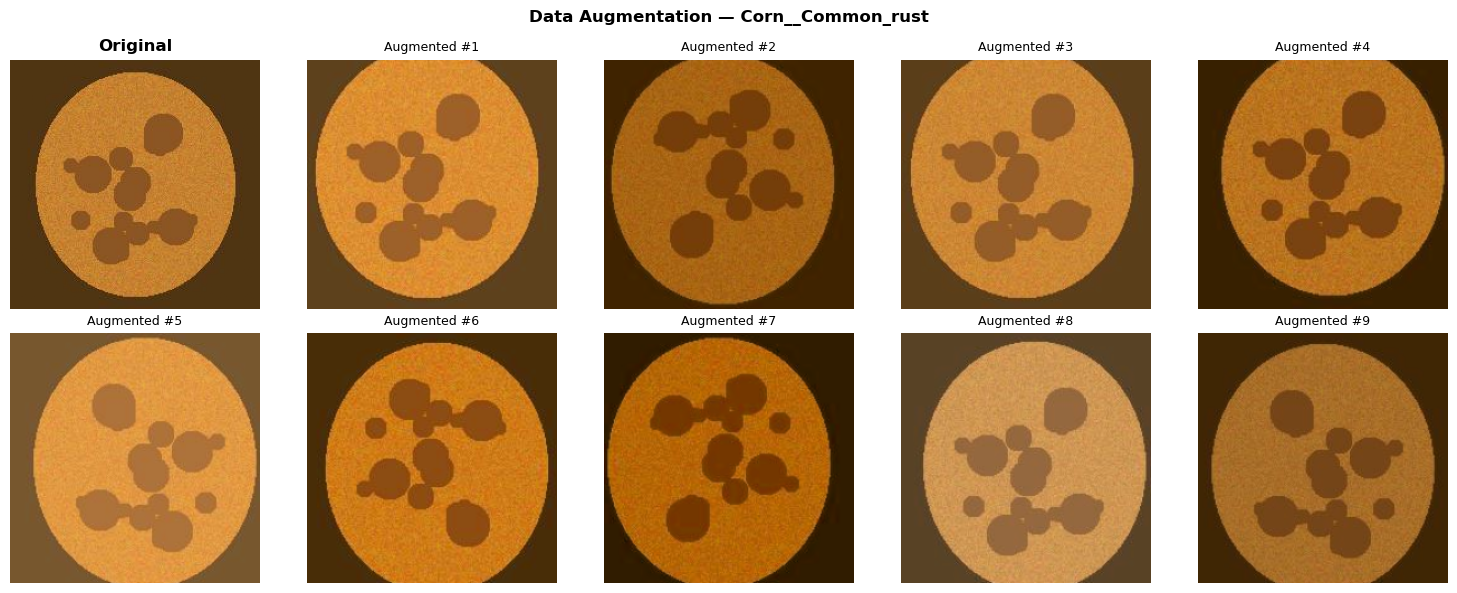

In [9]:
# Visualize augmentations on one sample 

sample_img_path = random.choice(list((train_data_dir / class_names[0]).glob('*.jpg')))
orig_img = tf.cast(tf.image.resize(
    tf.image.decode_jpeg(tf.io.read_file(str(sample_img_path)), channels=3),
    [224, 224]
), tf.float32) / 255.0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(orig_img.numpy())
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for idx in range(1, 10):
    aug, _ = augment(orig_img, 0)
    r, c = divmod(idx, 5)
    axes[r, c].imshow(aug.numpy())
    axes[r, c].set_title(f'Augmented #{idx}', fontsize=9)
    axes[r, c].axis('off')

plt.suptitle(f'Data Augmentation — {class_names[0]}', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/augmentation_samples.png", dpi=120, bbox_inches='tight')
plt.show()

In [1]:
# CELL 3.1 — Class Distribution
class_counts = {}
for cls_dir in sorted(DATA_DIR.iterdir()):
    if cls_dir.is_dir():
        imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.JPG')) + list(cls_dir.glob('*.png'))
        class_counts[cls_dir.name] = len(imgs)

df_cls = pd.DataFrame(list(class_counts.items()), columns=['Class','Count'])
df_cls = df_cls.sort_values('Count', ascending=False).reset_index(drop=True)

print('='*50)
print('          DATASET SUMMARY')
print('='*50)
print(f'  Total images : {df_cls.Count.sum():,}')
print(f'  Classes      : {len(df_cls)}')
print(f'  Max per class: {df_cls.Count.max():,}')
print(f'  Min per class: {df_cls.Count.min():,}')
print(f'  Mean         : {df_cls.Count.mean():.0f}')
print('='*50)

NameError: name 'DATA_DIR' is not defined